In [201]:
import numpy as np
import pandas as pd

from outliers import z_score, calculate_iqr, find_outliers_via_forest
from features import extract_features, split_data, prepare_data
from evaluate import evaluate_classification, save_evaluation_metrics, show_results
from define_pipeline import create_pipeline, tuning

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 777

In [202]:
df = pd.read_csv(filepath_or_buffer="Bank Customer Churn Prediction.csv")

In [203]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [204]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [205]:
df["customer_id"].unique().shape

(10000,)

In [206]:
df = df.drop(columns="customer_id")

### **Detecting Outliers & Anomalies**

In [207]:
numerical_cols = (
    df
    .drop(columns="churn")
    .select_dtypes(include=[np.number])
    .columns
)

anomalies = find_outliers_via_forest(
    df=df, 
    numerical_cols=numerical_cols, 
    contamination=0.05,
    to_scale=False
)

df = pd.concat(objs=[df, anomalies], ignore_index=False, axis="columns")

In [208]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,anomaly,score
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,0.094068
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,0.070199
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,0.028907
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1,0.056492
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1,0.079036


In [209]:
df.shape

(10000, 13)

In [210]:
df_anomalies = df[df["anomaly"] == -1]
df = df[df["anomaly"] == 1]

In [211]:
df.shape

(9500, 13)

### **Label Encoding**

In [212]:
df.info()

<class 'pandas.DataFrame'>
Index: 9500 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      9500 non-null   int64  
 1   country           9500 non-null   str    
 2   gender            9500 non-null   str    
 3   age               9500 non-null   int64  
 4   tenure            9500 non-null   int64  
 5   balance           9500 non-null   float64
 6   products_number   9500 non-null   int64  
 7   credit_card       9500 non-null   int64  
 8   active_member     9500 non-null   int64  
 9   estimated_salary  9500 non-null   float64
 10  churn             9500 non-null   int64  
 11  anomaly           9500 non-null   int64  
 12  score             9500 non-null   float64
dtypes: float64(3), int64(8), str(2)
memory usage: 1.0 MB


In [213]:
df["country"].value_counts()

country
France     4756
Germany    2389
Spain      2355
Name: count, dtype: int64

In [214]:
df["gender"].value_counts()

gender
Male      5222
Female    4278
Name: count, dtype: int64

In [215]:
def onehot_encode(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    encoder = OneHotEncoder(sparse_output=False)
    encoded = encoder.fit_transform(df[[column_name]])

    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out([column_name]),
        index=df.index
    )

    new_df = pd.concat([df.drop(columns=[column_name]), encoded_df], axis=1)

    return new_df

In [216]:
df = onehot_encode(df=df, column_name="country")
df = onehot_encode(df=df, column_name="gender")

In [217]:
df

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,anomaly,score,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0.094068,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0.070199,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0.028907,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0.056492,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0.079036,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1,0.113057,1.0,0.0,0.0,0.0,1.0
9996,516,35,10,57369.61,1,1,1,101699.77,0,1,0.053949,1.0,0.0,0.0,0.0,1.0
9997,709,36,7,0.00,1,0,1,42085.58,1,1,0.045117,1.0,0.0,0.0,1.0,0.0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0.103756,0.0,1.0,0.0,0.0,1.0


In [218]:
df.info()

<class 'pandas.DataFrame'>
Index: 9500 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      9500 non-null   int64  
 1   age               9500 non-null   int64  
 2   tenure            9500 non-null   int64  
 3   balance           9500 non-null   float64
 4   products_number   9500 non-null   int64  
 5   credit_card       9500 non-null   int64  
 6   active_member     9500 non-null   int64  
 7   estimated_salary  9500 non-null   float64
 8   churn             9500 non-null   int64  
 9   anomaly           9500 non-null   int64  
 10  score             9500 non-null   float64
 11  country_France    9500 non-null   float64
 12  country_Germany   9500 non-null   float64
 13  country_Spain     9500 non-null   float64
 14  gender_Female     9500 non-null   float64
 15  gender_Male       9500 non-null   float64
dtypes: float64(8), int64(8)
memory usage: 1.2 MB


In [219]:
df = df.drop(columns="anomaly")

### **Finding Correlation**

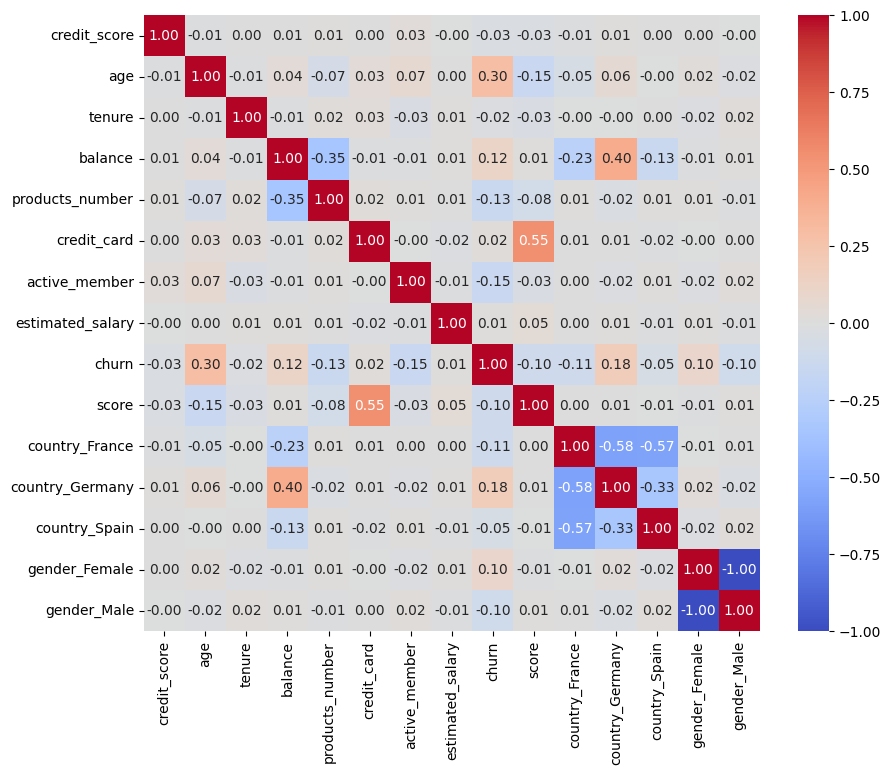

In [220]:
corr = df.corr(
    method="pearson",
    min_periods=1,
    numeric_only=False
)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.show()

### **Saving Prepared Dataset**

In [221]:
df.to_csv(path_or_buf="bank_churn_prepared.csv", index=False)

### **Random Forest Classifier**

In [222]:
df_pipeline, X, y = prepare_data(
    file_path="bank_churn_prepared.csv", 
    columns_to_be_dropped="churn", 
    target_column="churn"
)
num_features, cat_features = extract_features(df=df_pipeline)
X_train, X_test, y_train, y_test = split_data(X=X, y=y)

In [223]:
df_pipeline

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,score,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0.094068,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0.070199,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,0.028907,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0.056492,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0.079036,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9495,771,39,5,0.00,2,1,0,96270.64,0.113057,1.0,0.0,0.0,0.0,1.0
9496,516,35,10,57369.61,1,1,1,101699.77,0.053949,1.0,0.0,0.0,0.0,1.0
9497,709,36,7,0.00,1,0,1,42085.58,0.045117,1.0,0.0,0.0,1.0,0.0
9498,772,42,3,75075.31,2,1,0,92888.52,0.103756,0.0,1.0,0.0,0.0,1.0


In [224]:
model = RandomForestClassifier(
    n_estimators=500,        
    max_depth=20,            
    min_samples_split=5,     
    min_samples_leaf=2,      
    max_features="sqrt",     
    bootstrap=True,          
    n_jobs=-1,               
    random_state=RANDOM_STATE
)

pipeline = create_pipeline(
    model=model,
    num_features=num_features,
    cat_features=cat_features,
    scaler=StandardScaler(),
    encoder=None
)

pipeline.fit(X_train, y_train)

evaluation_metrics = evaluate_classification(
    model=pipeline,
    X_test=X_test,
    y_test=y_test,
    average="weighted",
    return_dict=True,
    verbose=True
)

show_results(results=evaluation_metrics)


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1537
           1       0.76      0.37      0.50       363

    accuracy                           0.86      1900
   macro avg       0.82      0.67      0.71      1900
weighted avg       0.85      0.86      0.84      1900

accuracy: 0.8578947368421053
precision: 0.8476196269912808
recall: 0.8578947368421053
f1: 0.8374749757830159
